Using device: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 5.70MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 520kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 1.65MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 492kB/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

[Epoch 0/50] [D loss: -0.1687] [G loss: -12.8010]
[Epoch 1/50] [D loss: -0.0398] [G loss: -4.7637]
[Epoch 2/50] [D loss: -0.5266] [G loss: -2.4851]
[Epoch 3/50] [D loss: -0.5662] [G loss: -4.2768]
[Epoch 4/50] [D loss: -0.5172] [G loss: -4.1167]
[Epoch 5/50] [D loss: -0.3587] [G loss: -3.3533]
[Epoch 6/50] [D loss: -0.4796] [G loss: -2.0383]
[Epoch 7/50] [D loss: -0.3805] [G loss: -2.0204]
[Epoch 8/50] [D loss: -0.3440] [G loss: -1.7878]
[Epoch 9/50] [D loss: -0.2527] [G loss: -2.1509]
[Epoch 10/50] [D loss: -0.4089] [G loss: -1.3317]
[Epoch 11/50] [D loss: -0.3868] [G loss: -1.4814]
[Epoch 12/50] [D loss: -0.3762] [G loss: -2.0856]
[Epoch 13/50] [D loss: -0.3799] [G loss: -1.5323]
[Epoch 14/50] [D loss: -0.3783] [G loss: -0.6556]
[Epoch 15/50] [D loss: -0.2857] [G loss: -0.9814]
[Epoch 16/50] [D loss: -0.2917] [G loss: -1.1169]
[Epoch 17/50] [D loss: -0.2323] [G loss: -1.0056]
[Epoch 18/50] [D loss: -0.2502] [G

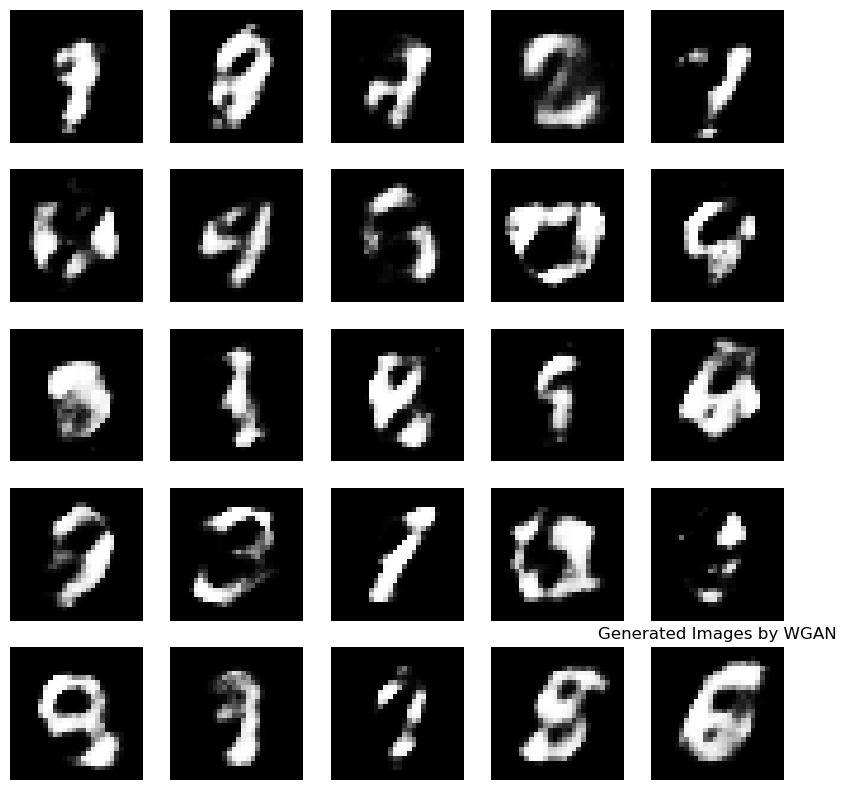

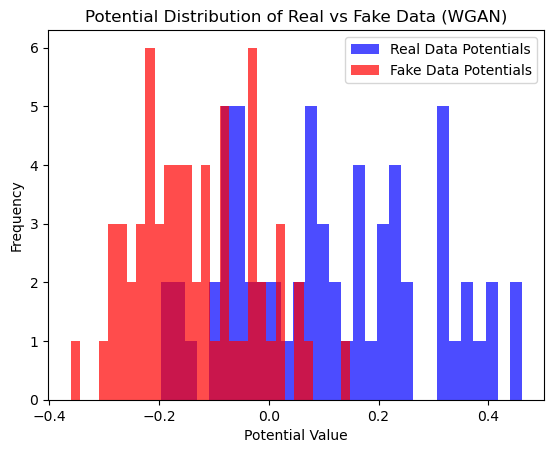

In [2]:
# ==============================
#         导入必要的库
# ==============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ==============================
#         设备配置
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================
#         数据准备
# ==============================
# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 加载 MNIST 数据集
batch_size = 64
train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# ==============================
#        判别器（势函数 f）
# ==============================
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)  # 标量输出作为势能
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平图像
        return self.model(x)

# ==============================
#         生成器 G
# ==============================
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784),
            nn.Tanh()  # 输出范围 [-1, 1]
        )

    def forward(self, z):
        return self.model(z).view(z.size(0), 1, 28, 28)

# ==============================
#      初始化模型和优化器
# ==============================
latent_dim = 100
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

# 定义优化器
lr = 0.00005
optimizer_G = optim.RMSprop(generator.parameters(), lr=lr)
optimizer_D = optim.RMSprop(discriminator.parameters(), lr=lr)

# 权重裁剪范围
clip_value = 0.01

# ==============================
#       训练参数设置
# ==============================
n_epochs = 50         # 训练轮数
n_critic = 5          # 每训练 5 次判别器，训练 1 次生成器

# ==============================
#          训练 WGAN
# ==============================
for epoch in range(n_epochs):
    for i, (real_imgs, _) in enumerate(train_loader):

        # ---------------------
        #  训练判别器
        # ---------------------
        optimizer_D.zero_grad()
        
        # 1️⃣ 真实数据势能
        real_imgs = real_imgs.view(real_imgs.size(0), -1).to(device)
        real_validity = discriminator(real_imgs)

        # 2️⃣ 生成器生成数据
        z = torch.randn(real_imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z)
        fake_validity = discriminator(fake_imgs.view(fake_imgs.size(0), -1))

        # 3️⃣ 计算判别器损失：最大化 E[f(x)] - E[f(G(z))]
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity)
        d_loss.backward()
        optimizer_D.step()

        # 4️⃣ 裁剪判别器权重到 [-clip_value, clip_value]
        for p in discriminator.parameters():
            p.data.clamp_(-clip_value, clip_value)

        # 每 n_critic 步更新一次生成器
        if i % n_critic == 0:
            # ---------------------
            #  训练生成器
            # ---------------------
            optimizer_G.zero_grad()

            # 生成数据的有效性
            z = torch.randn(real_imgs.size(0), latent_dim).to(device)
            gen_imgs = generator(z)
            fake_validity = discriminator(gen_imgs.view(gen_imgs.size(0), -1))

            # 生成器目标：最小化 -E[f(G(z))]，相当于最大化 E[f(G(z))]
            g_loss = -torch.mean(fake_validity)
            g_loss.backward()
            optimizer_G.step()

    print(f"[Epoch {epoch}/{n_epochs}] [D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

# ==============================
#     生成图像和势函数可视化
# ==============================

# 生成一些噪声
z = torch.randn(25, latent_dim).to(device)
gen_imgs = generator(z).detach().cpu().numpy()

# 绘制生成图像
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(gen_imgs[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
plt.title("Generated Images by WGAN")
plt.show()

# ==============================
#     判别器势函数分布可视化
# ==============================
real_imgs, _ = next(iter(train_loader))
real_imgs = real_imgs.view(real_imgs.size(0), -1).to(device)
real_validity = discriminator(real_imgs).detach().cpu().numpy()

# 计算生成数据的势能
z = torch.randn(real_imgs.size(0), latent_dim).to(device)
fake_imgs = generator(z)
fake_validity = discriminator(fake_imgs.view(fake_imgs.size(0), -1)).detach().cpu().numpy()

# 绘制真实数据和生成数据的势能分布
plt.hist(real_validity, bins=30, alpha=0.7, color="blue", label="Real Data Potentials")
plt.hist(fake_validity, bins=30, alpha=0.7, color="red", label="Fake Data Potentials")
plt.title("Potential Distribution of Real vs Fake Data (WGAN)")
plt.xlabel("Potential Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()
